In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#LOAD DATASET
df=pd.read_csv("/content/cleaned_morgan_stanley.csv")

**Task 2: Descriptive Transactional Analysis**

 **2.1** Calculate monthly and yearly summaries of total credits, debits, and net transaction
volume


In [ ]:
#If TransactionDate was saved as text, convert it back to datetime:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [ ]:
#checking the data saved or not
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [ ]:
#Create Year and Month columns
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month_name()

In [ ]:
#Deposit = Credit,Withdrawal = Debit,Payment = Debit
credit = df[df["TransactionType"] == "Deposit"]

debit = df[df["TransactionType"].isin(["Withdrawal", "Payment"])]

In [ ]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
#Monthly Credit
monthly_credit = credit.groupby(["Year", "Month"])["TransactionAmount"].sum()

print(monthly_credit)

Year  Month    
2023  April       649,054.23
      August      473,701.36
      December    540,703.00
      February    767,545.48
      January     739,627.61
      July        776,072.73
      June        536,127.62
      March       428,688.20
      May         467,715.55
      November    529,279.88
      October     954,771.22
      September   863,982.07
2024  April       547,272.22
      February    464,351.73
      January     582,366.95
      June        204,079.15
      March       713,940.90
      May         737,567.66
Name: TransactionAmount, dtype: float64


In [ ]:
#Monthly Debit
monthly_debit = debit.groupby(["Year", "Month"])["TransactionAmount"].sum()

print(monthly_debit)

Year  Month    
2023  April       1,735,600.31
      August        936,403.49
      December    1,099,611.11
      February    1,146,331.87
      January     1,225,847.22
      July          966,493.72
      June          609,895.93
      March       1,181,508.20
      May         1,693,535.98
      November    1,958,005.00
      October     1,714,706.35
      September   1,258,840.42
2024  April       1,004,444.88
      February    1,291,858.32
      January       864,788.85
      June        1,486,942.97
      March       1,045,983.99
      May           940,660.65
Name: TransactionAmount, dtype: float64


In [ ]:
#Net Transaction Volume
#Net = Credit − Debit
monthly_summary = pd.DataFrame()

monthly_summary["Credit"] = monthly_credit

monthly_summary["Debit"] = monthly_debit

monthly_summary = monthly_summary.fillna(0)

monthly_summary["Net"] = (
    monthly_summary["Credit"]
    - monthly_summary["Debit"]
)

print(monthly_summary)

                   Credit        Debit           Net
Year Month                                          
2023 April     649,054.23 1,735,600.31 -1,086,546.08
     August    473,701.36   936,403.49   -462,702.13
     December  540,703.00 1,099,611.11   -558,908.11
     February  767,545.48 1,146,331.87   -378,786.38
     January   739,627.61 1,225,847.22   -486,219.61
     July      776,072.73   966,493.72   -190,420.99
     June      536,127.62   609,895.93    -73,768.31
     March     428,688.20 1,181,508.20   -752,820.00
     May       467,715.55 1,693,535.98 -1,225,820.43
     November  529,279.88 1,958,005.00 -1,428,725.12
     October   954,771.22 1,714,706.35   -759,935.13
     September 863,982.07 1,258,840.42   -394,858.35
2024 April     547,272.22 1,004,444.88   -457,172.66
     February  464,351.73 1,291,858.32   -827,506.59
     January   582,366.95   864,788.85   -282,421.90
     June      204,079.15 1,486,942.97 -1,282,863.82
     March     713,940.90 1,045,983.99   -332,

**2.2**
Plot trends in total credits vs. debits over time.


In [ ]:
monthly_summary = monthly_summary.reset_index()

In [ ]:
#Create a proper date column for plotting
monthly_summary["Date"] = pd.to_datetime(
    monthly_summary["Month"] + " " + monthly_summary["Year"].astype(str),
    format="%B %Y"
)

In [ ]:
#Sort the data:
monthly_summary = monthly_summary.sort_values("Date")

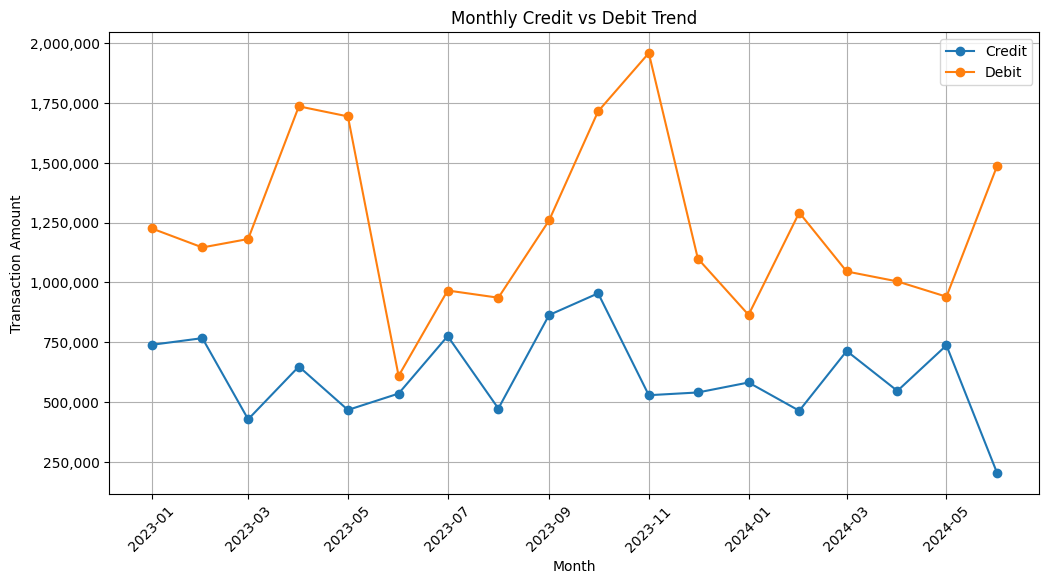

In [ ]:
#Plot Credit vs Debit
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


plt.figure(figsize=(12,6))

plt.plot(monthly_summary["Date"],
         monthly_summary["Credit"],
         marker="o",
         label="Credit")

plt.plot(monthly_summary["Date"],
         monthly_summary["Debit"],
         marker="o",
         label="Debit")

plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.show()

 **2.3**
 Identify top and bottom performing accounts based on net inflow

In [ ]:
#Create a NetAmount column
df["NetAmount"] = 0

In [ ]:
#Assign positive values for deposits:
df.loc[df["TransactionType"] == "Deposit", "NetAmount"] = df["TransactionAmount"]

/tmp/ipykernel_2284/1146302066.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 77104.45647    28719.95592    32006.0256     74244.98012
  53635.68928    50654.94487    74701.5369     39011.23849
  51130.95535    58493.03376    15576.59406    59276.48517
 107979.9353     61502.48708    69571.32611    67688.8152
  85474.13877    52336.34278     5380.233028   58306.19012
  47336.09655    11548.61194    52864.52119   116828.2616
  48295.7451     14600.9792    101840.3192     41583.91213
  58102.90956    38910.22395    69626.63321   105649.3145
  41141.4635     41145.93667    48958.41071    80583.87766
   -497.4282727  55877.7992     88154.87197    47702.2488
  57037.68144    88700.14908     4446.457245   66372.85081
  71686.40065    81819.63693    93088.79119    89534.95176
  66914.3664     16937.67889    45419.60309    59065.70872
  62730.77165    32148.7372     26451.36334    40017.19677
  36127.8993

In [ ]:
#Assign negative values for withdrawals and payments:
df.loc[df["TransactionType"].isin(["Withdrawal", "Payment"]), "NetAmount"] = -df["TransactionAmount"]

In [ ]:
#If you decide to treat transfers as debit:
df.loc[df["TransactionType"] == "Transfer", "NetAmount"] = -df["TransactionAmount"]

In [ ]:
#Calculate net inflow for each account
account_summary = df.groupby("AccountID")["NetAmount"].sum()

In [ ]:
#Top Performing Accounts
top_accounts = account_summary.sort_values(ascending=False).head(10)

print(top_accounts)

AccountID
ACC38559   195,846.24
ACC57700   171,403.14
ACC31539   128,947.20
ACC51971   115,097.31
ACC18177   102,494.72
ACC94907    99,517.27
ACC54589    97,067.46
ACC83581    83,274.25
ACC65545    76,716.66
ACC12334    74,852.58
Name: NetAmount, dtype: float64


In [ ]:
#Bottom Performing Accounts
bottom_accounts = account_summary.sort_values().head(10)

print(bottom_accounts)

AccountID
ACC61926   -693,174.04
ACC10117   -494,956.05
ACC51009   -493,622.95
ACC88449   -458,658.99
ACC19178   -428,726.77
ACC77592   -411,152.93
ACC71426   -408,217.40
ACC23736   -392,885.21
ACC16664   -376,020.63
ACC34431   -368,976.60
Name: NetAmount, dtype: float64


**2.4**
Identify and flag accounts as dormant or inactive if there is a gap of two months or more
between consecutive transactions.


In [ ]:
#Convert the date column
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [ ]:
#Sort the data
df = df.sort_values(["AccountID", "TransactionDate"])

In [ ]:
#Find the previous transaction date
df["PreviousTransaction"] = df.groupby("AccountID")["TransactionDate"].shift(1)

In [ ]:
#Calculate the gap
df["GapDays"] = (
    df["TransactionDate"] - df["PreviousTransaction"]
).dt.days

In [ ]:
#Flag dormant accounts Two months is approximately 60 days.
df["Status"] = "Active"

df.loc[df["GapDays"] >= 60, "Status"] = "Dormant"

In [ ]:
#Display dormant transactions
dormant_accounts = df[df["Status"] == "Dormant"]

print(dormant_accounts)

     TransactionID CustomerID AccountID AccountType TransactionType  \
555            173   CUST2067  ACC10117     Current        Transfer   
753             66   CUST6028  ACC10117        Loan      Withdrawal   
3              167   CUST5253  ACC10117        Loan         Payment   
137            169   CUST8461  ACC10996        Loan         Deposit   
515            119   CUST6319  ACC10996      Credit        Transfer   
..             ...        ...       ...         ...             ...   
113             84   CUST5500  ACC96868     Savings         Payment   
134             64   CUST9683  ACC97411        Loan         Deposit   
201            163   CUST5385  ACC99117     Savings      Withdrawal   
444             72   CUST8266  ACC99409        Loan        Transfer   
563            142   CUST4461  ACC99549      Credit         Deposit   

             Product    Firm   Region    Manager TransactionDate  ...  \
555    Personal Loan  Firm D     East  Manager 1      2023-04-30  ...   
7

In [ ]:
#Count dormant accounts
print(dormant_accounts["AccountID"].nunique())

167


In [ ]:
df.to_csv("processed_morgan_stanley.csv", index=False)